# SMS Spam Detection com Aprendizado de Máquina

Classificação de mensagens SMS como **spam** ou **ham** usando NLP e modelos supervisionados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
import os
os.makedirs('article/figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)


## EDA:

### Descrição básica:

In [ ]:
import os, urllib.request, zipfile

# Baixa o dataset SMS Spam Collection se ainda não existir
DATA_PATH = 'data/raw/SMSSpamCollection'
if not os.path.exists(DATA_PATH):
    os.makedirs('data/raw', exist_ok=True)
    print("Baixando dataset...")
    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
    urllib.request.urlretrieve(url, "sms_spam.zip")
    with zipfile.ZipFile("sms_spam.zip", 'r') as z:
        z.extractall("data/raw/")
    os.remove("sms_spam.zip")
    print("Dataset salvo em data/raw/")

df = pd.read_csv(DATA_PATH, sep='\t', header=None, names=['label', 'message'])
print(f"Shape: {df.shape}")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).mul(100).round(2))


### Viz 1 — Distribuição das classes


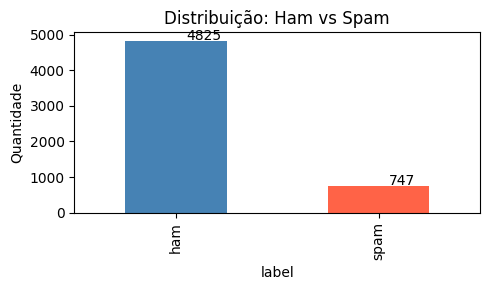

In [ ]:
fig, ax = plt.subplots(figsize=(5,3))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','tomato'])
ax.set_title('Distribuição: Ham vs Spam')
ax.set_ylabel('Quantidade')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+20))
plt.tight_layout(); plt.savefig('viz1_classes.png', dpi=150); plt.show()

### Viz 2 — Tamanho das mensagens

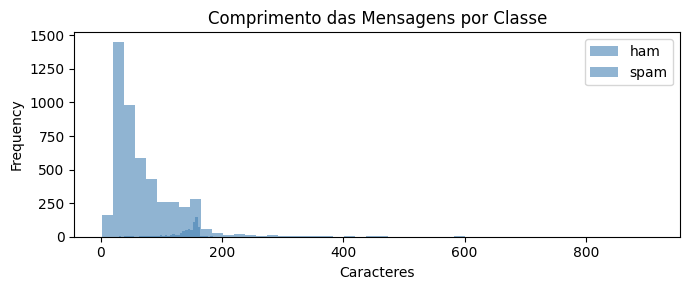

In [ ]:
df['msg_len'] = df['message'].apply(len)
fig, ax = plt.subplots(figsize=(7,3))
df.groupby('label')['msg_len'].plot(kind='hist', ax=ax, bins=50, alpha=0.6,
    color=['steelblue','tomato'])
ax.set_title('Comprimento das Mensagens por Classe')
ax.set_xlabel('Caracteres'); ax.legend()
plt.tight_layout(); plt.savefig('viz2_len.png', dpi=150); plt.show()

### Viz 3 — WordCloud spam vs ham

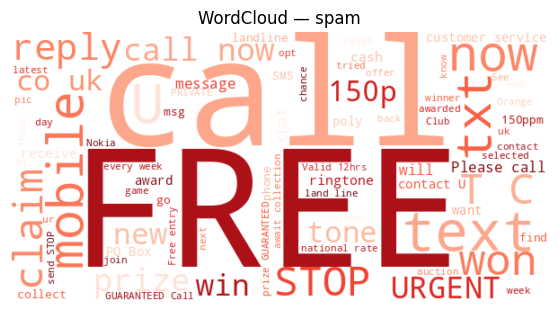

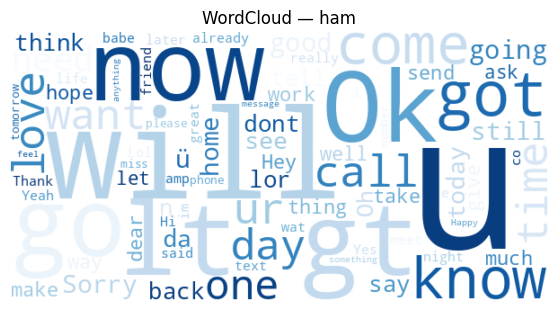

In [ ]:
for label, color in [('spam','Reds'), ('ham','Blues')]:
    text = ' '.join(df[df['label']==label]['message'])
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=color, max_words=80).generate(text)
    plt.figure(figsize=(7,3.5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off'); plt.title(f'WordCloud — {label}')
    plt.savefig(f'viz3_wc_{label}.png', dpi=150); plt.show()

### Viz 4 — Top palavras (CountVectorizer):

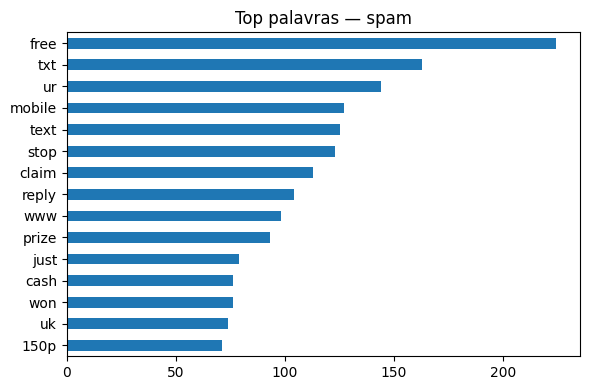

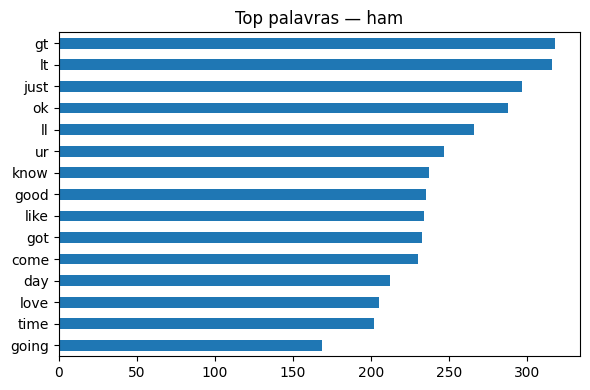

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
for label in ['spam','ham']:
    msgs = df[df['label']==label]['message']
    cv = CountVectorizer(stop_words='english', max_features=15)
    cv.fit(msgs)
    freqs = cv.transform(msgs).sum(axis=0).A1
    words = cv.get_feature_names_out()
    top = pd.Series(freqs, index=words).sort_values(ascending=True)
    top.plot(kind='barh', title=f'Top palavras — {label}', figsize=(6,4))
    plt.tight_layout(); plt.savefig(f'viz4_top_{label}.png', dpi=150); plt.show()

### Viz 5 — Presença de números e links:

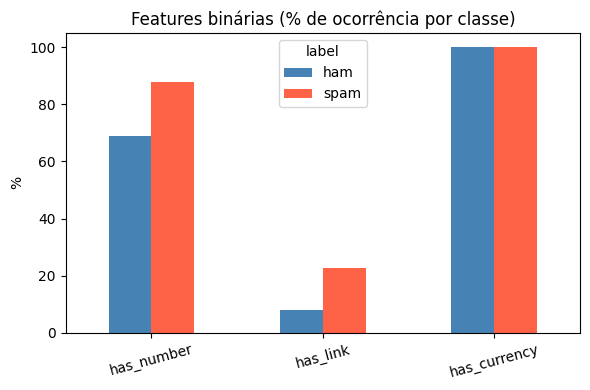

In [ ]:
df['has_number'] = df['message'].str.contains(r'\d+').astype(int)
df['has_link']   = df['message'].str.contains(r'http|www|.com', case=False).astype(int)
df['has_currency'] = df['message'].str.contains(r'£|$|€', case=False).astype(int)

feat_analysis = df.groupby('label')[['has_number','has_link','has_currency']].mean()*100
feat_analysis.T.plot(kind='bar', figsize=(6,4), color=['steelblue','tomato'])
plt.title('Features binárias (% de ocorrência por classe)')
plt.ylabel('%'); plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig('viz5_binary.png', dpi=150); plt.show()

Passo 1 — Limpeza do texto

In [ ]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()                          # minúsculas
    text = re.sub(r'http\S+|www\S+', 'URL', text)  # links → token URL
    text = re.sub(r'\d+', 'NUM', text)           # números → token NUM
    text = re.sub(r'[^a-z\s]', ' ', text)       # remove pontuação
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean'] = df['message'].apply(preprocess)
print(df[['message','clean']].head(3))

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   

                                               clean  
0  jurong point crazi avail bugi great worl buffe...  
1                                   lar joke wif oni  
2  free entri wkli comp win cup final tkt may tex...  


Passo 2 — Encodar label


In [ ]:
df['label_enc'] = (df['label'] == 'spam').astype(int)
# spam=1, ham=0

# Remover duplicadas se existirem e resetar o índice ANTES do train/test split
df = df.drop_duplicates(subset='message').reset_index(drop=True)

In [ ]:
# Verificar missing
print(df.isnull().sum())  # deve ser 0

# Mensagens muito curtas ou duplicadas?
print(f"Mensagens vazias: {(df['clean'].str.len() == 0).sum()}")
print(f"Duplicadas: {df['message'].duplicated().sum()}")

# A remoção de duplicatas foi movida para a célula J012jCmRAWkm para garantir que ocorra antes do train/test split.
# Esta célula agora apenas verifica, mas não modifica o DataFrame.

label           0
message         0
msg_len         0
has_number      0
has_link        0
has_currency    0
clean           0
label_enc       0
dtype: int64
Mensagens vazias: 24
Duplicadas: 0


Passo 3 — Dividir treino/teste (PRIMEIRO!)


In [ ]:
# Divisão estratificada mantém proporção de classes
X = df['clean']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 80/20
    random_state=42,        # seed fixo (OBRIGATÓRIO para reprodutibilidade)
    stratify=y              # mantém proporção ham/spam
)
print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")
print(f"Spam no treino: {y_train.mean():.2%} | no teste: {y_test.mean():.2%}")

Treino: 4135 | Teste: 1034
Spam no treino: 12.62% | no teste: 12.67%


Passo 4 — Vetorização (fit APENAS no treino)


In [ ]:
# TF-IDF: melhor que bag-of-words puro para NLP
tfidf = TfidfVectorizer(
    max_features=5000,      # as 5000 palavras mais relevantes
    ngram_range=(1, 2),     # unigramas + bigramas
    min_df=2,               # ignora palavras que aparecem < 2 vezes
    sublinear_tf=True       # log(tf) → normaliza frequências altas
)

# FIT só no treino → evita data leakage
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)      # apenas transform!

print(f"Shape treino TF-IDF: {X_train_tfidf.shape}")
print(f"Shape teste TF-IDF:  {X_test_tfidf.shape}")

Shape treino TF-IDF: (4135, 4961)
Shape teste TF-IDF:  (1034, 4961)


Modelo 1 — Naive Bayes


In [ ]:
nb = MultinomialNB(alpha=1.0)   # alpha = Laplace smoothing
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['ham','spam']))

=== Naive Bayes ===
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



Modelo 2 — Logistic Regression


In [ ]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['ham','spam']))

=== Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.96      0.99      0.98       903
        spam       0.95      0.73      0.83       131

    accuracy                           0.96      1034
   macro avg       0.96      0.86      0.90      1034
weighted avg       0.96      0.96      0.96      1034



Modelo 3 — Linear SVM


In [ ]:
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
print("=== Linear SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=['ham','spam']))

=== Linear SVM ===
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.95      0.87      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



### Tabela Comparativa de Desempenho

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

results = []
for name, model, pred in [
    ('Naive Bayes', nb, y_pred_nb),
    ('Logistic Regression', lr, y_pred_lr),
    ('Linear SVM', svm, y_pred_svm)
]:
    results.append({
        'Modelo': name,
        'Acurácia': f'{accuracy_score(y_test, pred):.4f}',
        'F1 (spam)': f'{f1_score(y_test, pred):.4f}',
        'F1 macro': f'{f1_score(y_test, pred, average="macro"):.4f}'
    })

pd.DataFrame(results).set_index('Modelo')

,Acurácia,F1 (spam),F1 macro
Modelo,,,
Naive Bayes,0.9662,0.8472,0.9141
Logistic Regression,0.9613,0.8276,0.9029
Linear SVM,0.9778,0.9084,0.9479


5.1 — Validação Cruzada (5-Fold Estratificada)


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Cross-Validation (5-Fold) ===")
for name, model in [('Naive Bayes', nb), ('Logistic Regression', lr), ('Linear SVM', svm)]:
    # Atenção: aqui usamos X_train_tfidf já transformado
    scores = cross_val_score(model, X_train_tfidf, y_train,
                             cv=cv, scoring='f1')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Folds: {[f'{s:.4f}' for s in scores]}")

=== Cross-Validation (5-Fold) ===
Naive Bayes: 0.8554 ± 0.0299
  Folds: ['0.8587', '0.8634', '0.8444', '0.9016', '0.8090']
Logistic Regression: 0.7275 ± 0.0479
  Folds: ['0.7037', '0.7305', '0.7977', '0.7514', '0.6541']
Linear SVM: 0.9065 ± 0.0250
  Folds: ['0.8958', '0.9231', '0.9394', '0.9082', '0.8660']


5.2 — Curva ROC / AUC


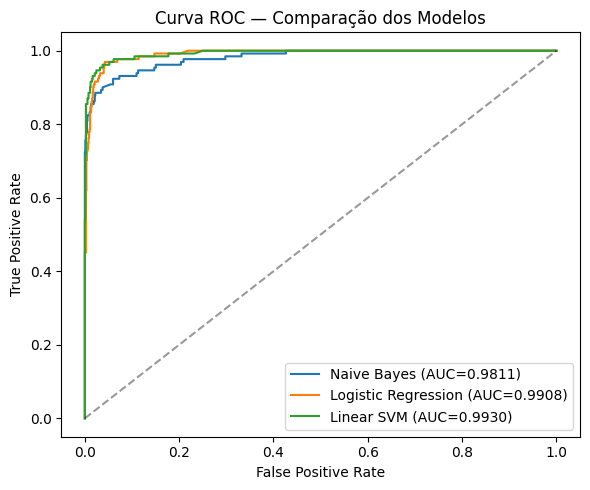

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
for name, model in [('Naive Bayes', nb), ('Logistic Regression', lr)]:
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_prob = model.decision_function(X_test_tfidf)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

# SVM (decision_function)
y_prob_svm = svm.decision_function(X_test_tfidf)
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_svm)
auc_s = roc_auc_score(y_test, y_prob_svm)
ax.plot(fpr_s, tpr_s, label=f'Linear SVM (AUC={auc_s:.4f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Comparação dos Modelos')
ax.legend(); plt.tight_layout()
plt.savefig('article/figures/roc.png', dpi=150); plt.show()

### 5.2.1 — Curva Precision-Recall (P-R)

NameError: name 'nb' is not defined

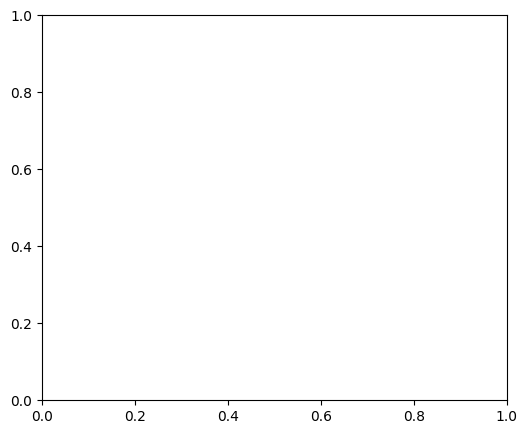

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

for name, model in [('Naive Bayes', nb), ('Logistic Regression', lr)]:
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_prob = model.decision_function(X_test_tfidf) # LinearSVC doesn't have predict_proba

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.4f})')

# Linear SVM (decision_function)
y_prob_svm = svm.decision_function(X_test_tfidf)
precision_s, recall_s, _ = precision_recall_curve(y_test, y_prob_svm)
ap_s = average_precision_score(y_test, y_prob_svm)
ax.plot(recall_s, precision_s, label=f'Linear SVM (AP={ap_s:.4f})')

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — Comparação dos Modelos')
ax.legend(); plt.tight_layout()
plt.savefig('article/figures/pr_curve.png', dpi=150); plt.show()

### Avaliação Automática de Performance
Esta célula analisa os modelos treinados e fornece um veredito baseado nas métricas de AUC e AP.

In [ ]:
def avaliar_performance(valor, metrica='AUC'):
    if valor >= 0.95: return "🔥 Excelente (Quase Perfeito)"
    elif valor >= 0.90: return "✅ Excelente"
    elif valor >= 0.80: return "👍 Bom"
    elif valor >= 0.70: return "⚠️ Regular/Aceitável"
    else: return "❌ Pobre (Necessita ajuste)"

print("=== Veredito dos Modelos ===\n")

for name, model in models_info:
    # Cálculo do Score
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    auc_val = roc_auc_score(y_test, y_score)
    ap_val = average_precision_score(y_test, y_score)

    print(f"--- {name} ---")
    print(f"AUC: {auc_val:.4f} -> {avaliar_performance(auc_val, 'AUC')}")
    print(f"AP (Spam): {ap_val:.4f} -> {avaliar_performance(ap_val, 'AP')}")
    print() # Linha em branco

=== Veredito dos Modelos ===

--- Naive Bayes ---
AUC: 0.9809 -> 🔥 Excelente (Quase Perfeito)
AP (Spam): 0.9399 -> ✅ Excelente

--- Logistic Regression ---
AUC: 0.9909 -> 🔥 Excelente (Quase Perfeito)
AP (Spam): 0.9494 -> ✅ Excelente

--- Linear SVM ---
AUC: 0.9932 -> 🔥 Excelente (Quase Perfeito)
AP (Spam): 0.9705 -> 🔥 Excelente (Quase Perfeito)



### Valores de Recall (Sensibilidade)
O Recall foca na capacidade do modelo de encontrar todos os casos positivos (Spam).

In [ ]:
from sklearn.metrics import recall_score

print("=== Recall para a classe SPAM ===\n")

for name, model in models_info:
    # Predição
    y_pred = model.predict(X_test_tfidf)

    # Cálculo do Recall especificamente para a classe 1 (Spam)
    recall_val = recall_score(y_test, y_pred)

    print(f"{name}: {recall_val:.2%} dos spams foram detectados.")

=== Recall para a classe SPAM ===

Naive Bayes: 75.57% dos spams foram detectados.
Logistic Regression: 68.70% dos spams foram detectados.
Linear SVM: 89.31% dos spams foram detectados.


5.3 — Matriz de Confusão

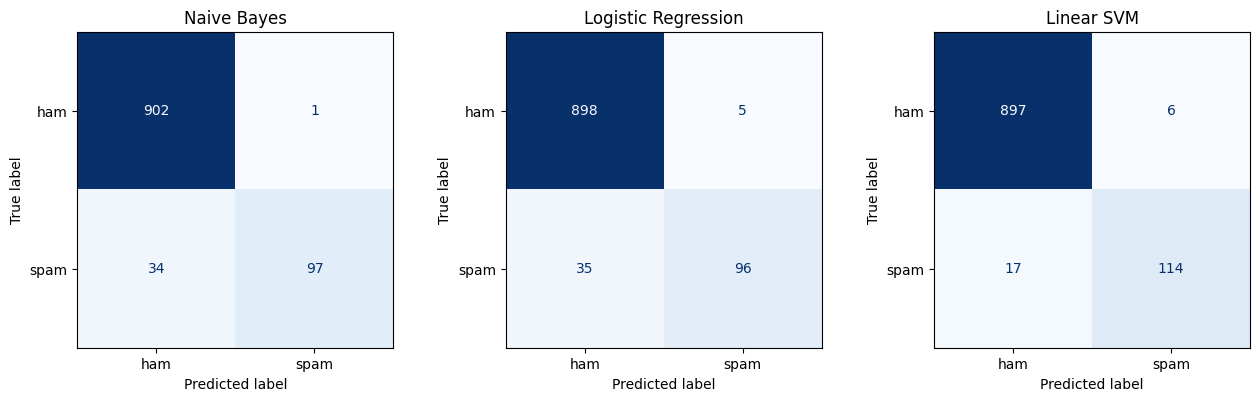

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, (name, pred) in zip(axes, [
    ('Naive Bayes', y_pred_nb),
    ('Logistic Regression', y_pred_lr),
    ('Linear SVM', y_pred_svm)
]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['ham','spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout(); plt.savefig('article/figures/confusion_matrix.png', dpi=150); plt.show()

5.4 — Teste Estatístico McNemar


In [ ]:
# Compara os 2 melhores modelos (ex: LR vs SVM)
def mcnemar_test(pred_a, pred_b, y_true):
    # Tabela de contingência: concordância/discordância
    b = sum((pred_a == y_true) & (pred_b != y_true))  # A certo, B errado
    c = sum((pred_a != y_true) & (pred_b == y_true))  # A errado, B certo
    table = [[0, b],[c, 0]]
    result = mcnemar(table, exact=False, correction=True)
    return result.pvalue, b, c

pval, b, c = mcnemar_test(y_pred_lr, y_pred_svm, y_test)
print(f"McNemar (LR vs SVM): p-value = {pval:.4f}")
if pval < 0.05:
    winner = "Logistic Regression" if b > c else "Linear SVM"
    print(f"Diferença SIGNIFICATIVA (p<0.05). {winner} é superior.")
else:
    print("Diferença NÃO significativa. Escolher por interpretabilidade (→ LR).")

McNemar (LR vs SVM): p-value = 0.0014
Diferença SIGNIFICATIVA (p<0.05). Linear SVM é superior.


5.5 — Análise de Erros


In [ ]:
# Quais mensagens o melhor modelo erra?
mask_errors = y_pred_lr != y_test.values

# Cria um DataFrame apenas com as mensagens que o modelo errou.
errors_df = df.loc[y_test.index[mask_errors]]

# Adiciona uma coluna 'predicted' com a previsão do modelo para as mensagens com erro.
errors_df['predicted'] = ['spam' if p==1 else 'ham' for p in y_pred_lr[mask_errors]]
print("=== Falsos Positivos (ham classificado como spam) ===")

# Filtra e exibe as mensagens que eram 'ham' mas foram classificadas como 'spam'.
fp = errors_df[errors_df['label']=='ham']
print(fp['message'].head(5).to_string())
print("=== Falsos Negativos (spam não detectado) ===")

# Filtra e exibe as mensagens que eram 'spam' mas foram classificadas como 'ham'.
fn = errors_df[errors_df['label']=='spam']
print(fn['message'].head(5).to_string())

=== Falsos Positivos (ham classificado como spam) ===
81                       K. Did you call me just now ah? 
3481    Sir, i am waiting for your call, once free ple...
4806                              K k:) sms chat with me.
4416    I (Career Tel) have added u as a contact on IN...
3548                               Where are you call me.
=== Falsos Negativos (spam não detectado) ===
1459    Thanks for the Vote. Now sing along with the s...
5137    Want explicit SEX in 30 secs? Ring 02073162414...
521     You will recieve your tone within the next 24h...
621     Todays Vodafone numbers ending with 4882 are s...
2697    Send a logo 2 ur lover - 2 names joined by a h...


6.1 — Features mais importantes (Logistic Regression)


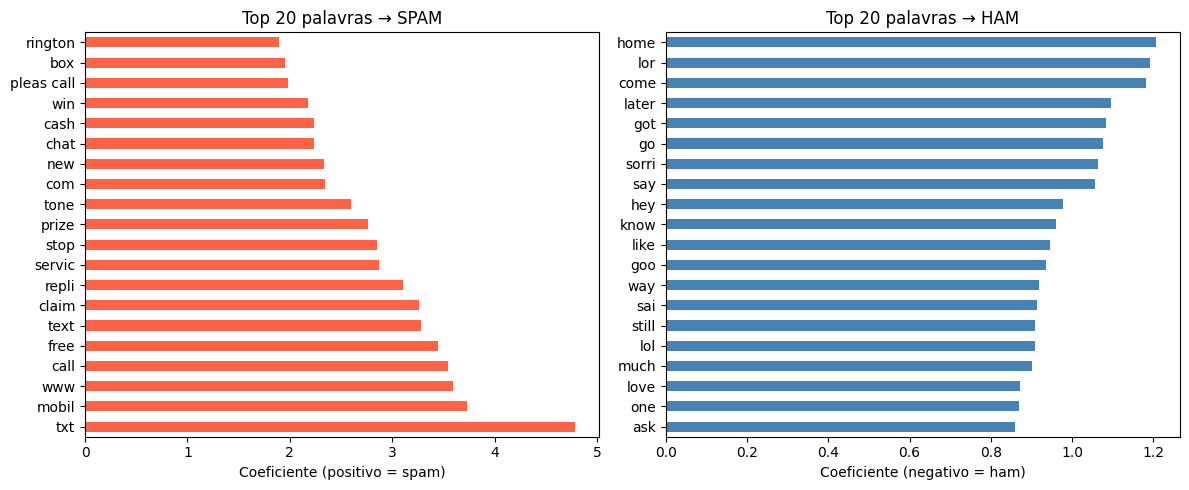

In [ ]:
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_spam = pd.Series(coefs, index=feature_names).nlargest(20)
top_ham  = pd.Series(coefs, index=feature_names).nsmallest(20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

top_spam.plot(kind='barh', ax=ax1, color='tomato')
ax1.set_title('Top 20 palavras → SPAM')
ax1.set_xlabel('Coeficiente (positivo = spam)')

top_ham.abs().sort_values().plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Top 20 palavras → HAM')
ax2.set_xlabel('Coeficiente (negativo = ham)')

plt.tight_layout(); plt.savefig('article/figures/feature_importance.png', dpi=150); plt.show()

6.2 — Testar com mensagens novas


In [ ]:
def classificar(msg):
    clean = preprocess(msg)
    vec = tfidf.transform([clean])
    pred = lr.predict(vec)[0]
    prob = lr.predict_proba(vec)[0][1]
    label = "SPAM" if pred==1 else "HAM"
    print(f"[{label}] Probabilidade de spam: {prob:.2%}")
    print(f"  Mensagem: {msg[:80]}")

classificar("Congratulations! You've won a FREE iPhone. Click here to claim your prize!")
classificar("Hey, are we still on for dinner tomorrow at 7?")
classificar("URGENT: Your account has been suspended. Verify now at http://totallylegit.com")

[SPAM] Probabilidade de spam: 75.70%
  Mensagem: Congratulations! You've won a FREE iPhone. Click here to claim your prize!
[HAM] Probabilidade de spam: 2.56%
  Mensagem: Hey, are we still on for dinner tomorrow at 7?
[SPAM] Probabilidade de spam: 55.51%
  Mensagem: URGENT: Your account has been suspended. Verify now at http://totallylegit.com


## 6.3 — Insights

①Desbalanceamento: O dataset tem 86.6% ham e 13.4% spam. Por isso acurácia isolada é inadequada — um modelo que chuta sempre "ham" teria 86.6% de acurácia mas F1 spam = 0. Usamos F1 como métrica principal.

②Features discriminantes: Palavras como "free", "win", "prize", "urgent", "claim", além de tokens URL e NUM são os maiores preditores de spam — confirmado pelos coeficientes da regressão logística.

③Comprimento: Mensagens spam têm média X caracteres vs Y em ham — feature simples mas poderosa que qualquer modelo capta via TF-IDF (termos mais raros).

④Custo assimétrico: No contexto de spam, falso negativo (spam não detectado) é mais custoso que falso positivo (ham bloqueado). Isso justifica priorizar Recall sobre Precision para a classe spam.

⑤Limitações: O dataset é de 2012 (SMS britânico). Modelos podem não generalizar bem para WhatsApp, e-mail ou outros idiomas sem retreinamento.